# background_stats

> Calculate statistics to determine the surface brightness and spatial scale of the background variations.

In [ ]:
# | default_exp euclid.background_stats

In [ ]:
# | export

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from astropy.io import fits
from astropy import table
from astropy.convolution import convolve, TrapezoidDisk2DKernel
from matplotlib.ticker import FuncFormatter, NullLocator
from matplotlib import patheffects as pe

from photutils.aperture import (
    CircularAperture,
    CircularAnnulus,
    RectangularAperture,
    RectangularAnnulus,
    ApertureStats,
)
from tqdm import tqdm

from nicl.mask import fast_mask, plot_mask

In [ ]:
# | hide

from FyeldGenerator import generate_field
from scipy.stats import norm

from nicl.euclid.utilities import default_data_path


In [ ]:
# | export


def aperture_stats(
    data,
    mask,
    n_apertures,
    sqrt_n_pix,
    aperture_shape,
    annular_thickness=None,
    n_pix_tolerance=0.1,
):
    if aperture_shape == "square":
        outer_size = sqrt_n_pix
    if aperture_shape == "circle":
        outer_size = sqrt_n_pix * 2 / np.sqrt(np.pi)

    # adjust aperture sizes to account, on average, for masked pixels
    unmasked_frac = 1 - mask.sum() / mask.size
    outer_size /= np.sqrt(unmasked_frac)

    annulus = annular_thickness is not None and annular_thickness < 1
    if sqrt_n_pix < 3:
        # does not make sense to use an annulus for small numbers of pixels
        annulus = False
    
    if annulus:
        outer_size = outer_size / np.sqrt(1 - (1 - annular_thickness) ** 2)
        inner_size = (1 - annular_thickness) * outer_size
    else:
        inner_size = 0

    x = np.random.uniform(outer_size / 2, data.shape[1] - outer_size / 2, n_apertures)
    y = np.random.uniform(outer_size / 2, data.shape[0] - outer_size / 2, n_apertures)
    positions = np.transpose(np.vstack((x, y)))

    if aperture_shape == "square":
        if annulus:
            ap = RectangularAnnulus(
                positions,
                w_in=inner_size,
                w_out=outer_size,
                h_in=inner_size,
                h_out=outer_size,
            )
        else:
            ap = RectangularAperture(positions, w=outer_size, h=outer_size)
    elif aperture_shape == "circle":
        if annulus:
            ap = CircularAnnulus(positions, r_in=inner_size / 2, r_out=outer_size / 2)
        else:
            ap = CircularAperture(positions, r=outer_size / 2)

    stats = ApertureStats(data, ap, mask=mask, sum_method="center")
    stats = stats.to_table(columns=("sum_aper_area", "mean", "median"))
    n_pix = sqrt_n_pix**2
    achieved_n_pix = stats["sum_aper_area"].value
    ok = abs(achieved_n_pix - n_pix) / n_pix < n_pix_tolerance
    n_ok = ok.sum()
    stats = stats[ok]
    std_mean = np.std(stats["mean"])
    err_std_mean = std_mean / np.sqrt(2 * n_ok - 2)
    std_median = np.std(stats["median"])
    err_std_median = std_median / np.sqrt(2 * n_ok - 2)
    results = dict(
        sqrt_n_pix=sqrt_n_pix,
        std_mean=std_mean,
        err_std_mean=err_std_mean,
        std_median=std_median,
        err_std_median=err_std_median,
        n_ok=n_ok,
        outer_size=outer_size,
    )
    return results

In [ ]:
# | export


def stats_versus_size(
    data,
    mask,
    n_apertures,
    max_sqrt_n_pix,
    aperture_shape,
    annular_thickness=None,
    n_pix_tolerance=0.1,
    n_steps=20,
):
    sqrt_n_pix_list = np.logspace(0, np.log10(max_sqrt_n_pix), n_steps)
    sqrt_n_pix_list = np.unique(sqrt_n_pix_list.astype(int))
    results = []
    for sqrt_n_pix in tqdm(sqrt_n_pix_list):
        results.append(
            aperture_stats(
                data,
                mask,
                n_apertures=n_apertures,
                sqrt_n_pix=sqrt_n_pix,
                aperture_shape=aperture_shape,
                annular_thickness=annular_thickness,
                n_pix_tolerance=n_pix_tolerance,
            )
        )
    results = table.Table(results)
    results["expected_std_mean"] = results["std_mean"][0] / results["sqrt_n_pix"]
    results["expected_std_median"] = (
        np.sqrt(np.pi / 2) * results["std_median"][0] / results["sqrt_n_pix"]
    )
    return results

In [ ]:
# | export

def convert_to_mag(results, zp):
    results["expected_std_mean"] = zp - 2.5 * np.log10(results["expected_std_mean"])
    results["expected_std_median"] = zp - 2.5 * np.log10(results["expected_std_median"])
    results["std_mean"] = zp - 2.5 * np.log10(results["std_mean"])
    results["std_median"] = zp - 2.5 * np.log10(results["std_median"])
    return results

In [ ]:
# | export


def background_stats_plot(results, true_bkg_std=None, errorbars=False, zp_mag=None, filename=None):
    if zp_mag is not None:
        results = convert_to_mag(results, zp_mag)
    fig, ax = plt.subplots()
    ax.plot(
        results["sqrt_n_pix"],
        results["expected_std_mean"],
        "--",
        label="expected std(mean)",
    )
    if errorbars:
        ax.errorbar(
            results["sqrt_n_pix"],
            results["std_mean"],
            results["err_std_mean"],
            fmt="-o",
            label="measured std(mean)",
        )
    else:
        ax.plot(
            results["sqrt_n_pix"], results["std_mean"], "-o", label="measured std(mean)"
        )
    ax.plot(
        results["sqrt_n_pix"],
        results["expected_std_median"],
        "--",
        label="expected std(median)",
    )
    if errorbars:
        ax.errorbar(
            results["sqrt_n_pix"],
            results["std_median"],
            results["err_std_mean"],
            fmt="-o",
            label="measured std(median)",
        )
    else:
        ax.plot(
            results["sqrt_n_pix"],
            results["std_median"],
            "-o",
            label="measured std(median)",
        )
    if true_bkg_std is not None:
        ax.axhline(true_bkg_std, ls=":", label="true bkg std")
    ax.set_xscale("log")
    if zp_mag is None:
        ax.set_yscale("log")
    else:
        ax.yaxis.set_inverted(True)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
    ax.xaxis.set_ticks(results["sqrt_n_pix"])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xlabel("sqrt(n_pix)")
    ax.set_ylabel("std(average)")
    ax.tick_params(axis='x', labelrotation=90)
    ax.legend()
    if filename is not None:
        fig.savefig(filename)

In [ ]:
# | export


def measure(
    filename,  # the filename to test
    path,  # the folder containing the images
    mask=None,  # an optional mask to apply to the image
    create_mask=True,  # generate and apply a mask if not supplied
    estimate_background=True,  # allow masking to estimate the background from the median of the image
    plots=True,  # output plots
    outpath=None,  # the folder where all output plots should be placed
    separate_detectors=True,  # consider multiple science extensions individually
    n_apertures=1000,  # number of apertures per size
    max_sqrt_n_pix=250,  # maximum aperture size as sqrt(number of pixels)
    aperture_shape="square",  # square or circle
    annular_thickness=None,  # None for solid apertures, or a number on range (0, 1) to specify relative thickness of annulus
    n_pix_tolerance=0.1,  # the largest allowed relative deviation from the requested n_pix
    n_steps=25,  # the number of different sqrt_n_pix to measure
    zp_mag=21.286,  # convert to magntiudes using this zero point, unless it is None
):
    """Determine statistics of the background."""
    path = Path(path).expanduser()
    if outpath is not None:
        outpath = Path(outpath).expanduser()
    else:
        outpath = path / "background_stats"
    results = {}
    fn = path / filename
    with fits.open(fn, memmap=True) as hdul:
        sci_ext = [hdu.name for hdu in hdul if "SCI" in hdu.name]
        multi_ext = len(sci_ext) > 1
        for ext in sci_ext:
            data = hdul[ext].data
            rms = hdul[ext.replace("SCI", "RMS")].data
            data[rms > 1e6] = np.nan
            if create_mask:
                mask, _ = fast_mask(data, estimate_background=estimate_background)
            else:
                mask = np.zeros(data.shape, dtype=bool)
            ext_results = stats_versus_size(
                data,
                mask,
                n_apertures=n_apertures,
                max_sqrt_n_pix=max_sqrt_n_pix,
                aperture_shape=aperture_shape,
                annular_thickness=annular_thickness,
                n_pix_tolerance=n_pix_tolerance,
                n_steps=n_steps,
            )
            if multi_ext:
                outfile = (outpath / filename).with_suffix(f"_{ext}.fits")
            else:
                outfile = (outpath / filename).with_suffix(".fits")
            outfile.parent.mkdir(parents=True, exist_ok=True)
            ext_results.write(outfile, overwrite=True)
            if plots:
                if multi_ext:
                    outfile = (outpath / filename).with_suffix(f"_{ext}.pdf")
                else:
                    outfile = (outpath / filename).with_suffix(".pdf")
                background_stats_plot(ext_results, zp_mag=zp_mag, filename=outfile)
            results[ext] = ext_results
    if not separate_detectors:
        results = table.vstack(results.values())
    elif len(results) == 1:
        results = list(results.values())[0]
    return results

## Test

Test the performance on images containing random noise and a background varying on a particular spatial scale.

In [ ]:
def _distrib(shape):
    a = np.random.normal(loc=0, scale=1, size=shape)
    b = np.random.normal(loc=0, scale=1, size=shape)
    return a + 1j * b


def create_test_background(
    shape=(2040, 1020),  # shape of the simulated image,
    rms=1.0,  # rms of the Gaussian background noise, in absence of spatial variations
    background_scale=100,  # scale, in pixels, of the spatial background variations
    background_rms=0.1,  # rms of the spatial background variations
):  # `random`, `background`, `random_with_background`
    """Create a background image for testing.

    A `random` flat background is created by sampling a Gaussian distribution with the
    specified `rms`. A spatially varying `background` is created as a Gaussian random field,
    with a Gaussian power spectrum, centred at zero wavelength with a standard deviation of
    0.1 / `background_scale`. This produces smooth spatial features on scales on the order of
    `background_scale`. This spatially varying background is scaled to have an rms of`
    `background_rms`. The two are summed to produce `random_with_background`.
    """
    random = norm(0, rms).rvs(size=shape)
    background = generate_field(_distrib, norm(0, 0.1 / background_scale).pdf, shape)
    background *= background_rms / background.std()
    random_with_background = random + background
    return random, background, random_with_background


def create_test_mask(
    shape=(2040, 1020),  # shape of the simulated image,
    scale=100,  # scale, in pixels, of the spatial variations used to create the mask
    threshold=1.5,  # threshold of the spatial variations, as a multiple of the rms
):  # boolean `mask`, in which True means a pixel should be masked
    """Create an arbitrary mask for testing, by thresholding a Guassian random field."""
    mask = generate_field(_distrib, norm(0, 1 / scale).pdf, shape)
    mask = mask > threshold * mask.std()
    return mask

In [ ]:
def correlate_pixels(img, slope=0.8):
    kernel = TrapezoidDisk2DKernel(0, slope)
    n = kernel.shape[0]
    f_centre = kernel.array[(n - 1)//2, (n - 1)//2]
    print(f"Fraction of flux in central pixel is {100*f_centre:.0f}%")
    convolved_img = convolve(img, kernel)
    return convolved_img

In [ ]:
random, background, random_with_background = create_test_background()

In [ ]:
random_convolved = correlate_pixels(random, slope=0.8)
random_with_background_convolved = random_convolved + background

Fraction of flux in central pixel is 56%


In [ ]:
mask = create_test_mask()
no_mask = mask * False

In [ ]:
def plot_test_images(random, background, random_with_background, mask, circles=True):
    fig, ax = plt.subplots(1, 4, figsize=(12, 6))
    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
    vmin, vmax = np.percentile(random, (0.1, 99.9))
    ax[0].imshow(random, vmin=vmin, vmax=vmax, cmap="seismic", interpolation="none")
    ax[1].imshow(background, vmin=vmin, vmax=vmax, cmap="seismic", interpolation="none")
    ax[2].imshow(random_with_background, vmin=vmin, vmax=vmax, cmap="seismic", interpolation="none")
    ax[3].imshow(mask, cmap="seismic", interpolation="none")
    if circles:
        x = 120
        for i, radius in enumerate((10, 20, 40, 80)):
            circle = plt.Circle((x + radius, 150), radius, ec="w", fc="none", lw=5)
            ax[1].add_patch(circle)
            circle = plt.Circle((x + radius, 150), radius, ec="k", fc="none")
            ax[1].add_patch(circle)
            rlabel = "r=" if i == 0 else ""
            ax[1].annotate(f"{rlabel}{radius}px", (x + radius, 220 + radius), ha="center", color="k",
                           path_effects=[pe.withStroke(linewidth=4, foreground="white")])
            x += 2 * radius + 160
    plt.tight_layout()

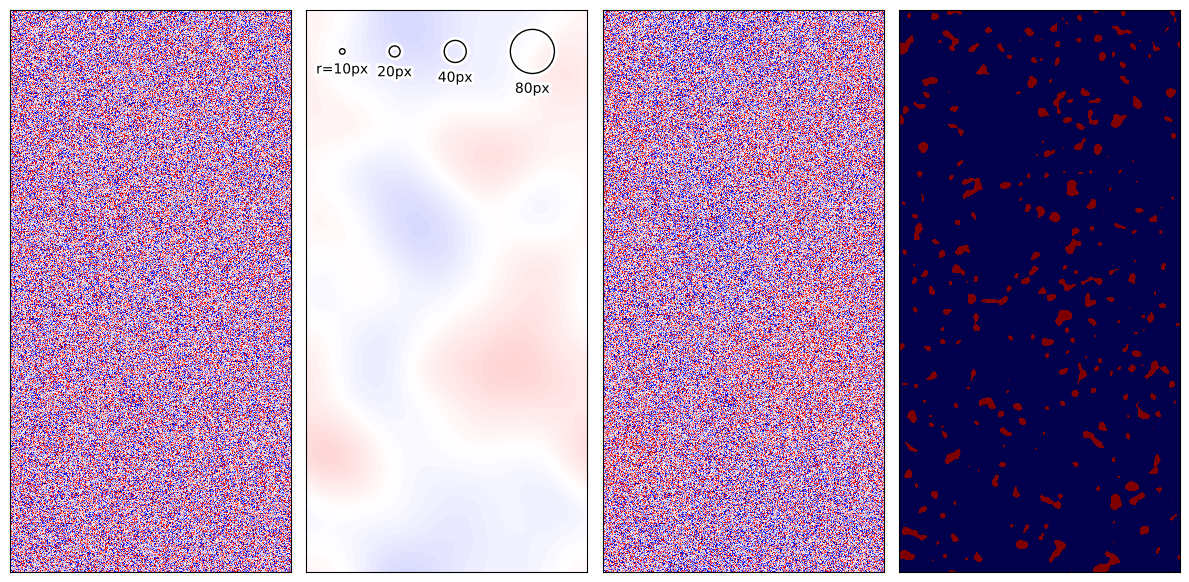

In [ ]:
plot_test_images(random, background, random_with_background, mask, circles=True)

Calculate the standard deviation of the average over many apertures of a given size.

First with no mask and square apertures.

In [ ]:
results = aperture_stats(
    random,
    no_mask,
    n_apertures=100,
    sqrt_n_pix=100,
    aperture_shape="square",
    annular_thickness=None,
    n_pix_tolerance=0.1,
)
assert results["n_ok"] == 100
results

{'sqrt_n_pix': 100,
 'std_mean': 0.011005318712059887,
 'err_std_mean': 0.0007821139443776573,
 'std_median': 0.013284683988056807,
 'err_std_median': 0.0009441013809372063,
 'n_ok': 100,
 'outer_size': 100.0}

Now with a mask, note that `n_ok` decrease a bit, but the `outer_size` has increased to compensate for the masking.

In [ ]:
aperture_stats(random, mask, n_apertures=100, sqrt_n_pix=100, aperture_shape="square")

{'sqrt_n_pix': 100,
 'std_mean': 0.008534431011687545,
 'err_std_mean': 0.0006191527007181674,
 'std_median': 0.011889310921317139,
 'err_std_median': 0.0008625412703589167,
 'n_ok': 96,
 'outer_size': 103.46690208333058}

Let's compare the original and convolved images for a single pixel.

In [ ]:
aperture_stats(random, mask, n_apertures=100, sqrt_n_pix=1, aperture_shape="square")

{'sqrt_n_pix': 1,
 'std_mean': 1.0468844552878502,
 'err_std_mean': 0.08225101082809155,
 'std_median': 1.0468844552878502,
 'err_std_median': 0.08225101082809155,
 'n_ok': 82,
 'outer_size': 1.0346690208333058}

In [ ]:
aperture_stats(random_convolved, mask, n_apertures=100, sqrt_n_pix=1, aperture_shape="square")

{'sqrt_n_pix': 1,
 'std_mean': 0.5692923024077082,
 'err_std_mean': 0.044727827501088134,
 'std_median': 0.5692923024077082,
 'err_std_median': 0.044727827501088134,
 'n_ok': 82,
 'outer_size': 1.0346690208333058}

Try a square annulus. The `outer_size` has increased to achieve the same number of pixels.

In [ ]:
aperture_stats(
    random,
    mask,
    n_apertures=100,
    sqrt_n_pix=100,
    aperture_shape="square",
    annular_thickness=0.5,
)

{'sqrt_n_pix': 100,
 'std_mean': 0.009725202440204804,
 'err_std_mean': 0.0007208799663192684,
 'std_median': 0.011947998054527911,
 'err_std_median': 0.000885644539338698,
 'n_ok': 92,
 'outer_size': 119.47328754005513}

Try a circle. The `outer_size` has increased to achieve the same number of pixels as a square.

In [ ]:
aperture_stats(random, mask, n_apertures=100, sqrt_n_pix=100, aperture_shape="circle")

{'sqrt_n_pix': 100,
 'std_mean': 0.009421973891325078,
 'err_std_mean': 0.0006835418287312953,
 'std_median': 0.013189522942368144,
 'err_std_median': 0.0009568685644969209,
 'n_ok': 96,
 'outer_size': 116.74989679474152}

Try a circular annulus. Again, the `outer_size` has increased to achieve the same number of pixels.

In [ ]:
aperture_stats(
    random,
    mask,
    n_apertures=100,
    sqrt_n_pix=100,
    aperture_shape="circle",
    annular_thickness=0.5,
)

{'sqrt_n_pix': 100,
 'std_mean': 0.009592699309747939,
 'err_std_mean': 0.0007149975914770567,
 'std_median': 0.012795499582555148,
 'err_std_median': 0.0009537202290887831,
 'n_ok': 91,
 'outer_size': 134.8111686846101}

Now try with a spatially varying background. On small scales, the standard deviations match the original pixel rms, but on larger scales they match the strength of the background variations.

In [ ]:
aperture_stats(
    random_with_background, mask, n_apertures=100, sqrt_n_pix=1, aperture_shape="square"
)

{'sqrt_n_pix': 1,
 'std_mean': 0.9836134072686238,
 'err_std_mean': 0.07173738064422645,
 'std_median': 0.9836134072686238,
 'err_std_median': 0.07173738064422645,
 'n_ok': 95,
 'outer_size': 1.0346690208333058}

In [ ]:
aperture_stats(
    random_with_background,
    mask,
    n_apertures=1000,
    sqrt_n_pix=100,
    aperture_shape="square",
)

{'sqrt_n_pix': 100,
 'std_mean': 0.10100108585842635,
 'err_std_mean': 0.0023469592643782216,
 'std_median': 0.1009859560538906,
 'err_std_median': 0.002346607693554783,
 'n_ok': 927,
 'outer_size': 103.46690208333058}

Now let's measure the statistics in apertures of a series of sizes. First with no spatially varying background.

In [ ]:
results_no_bkg = stats_versus_size(
    random, mask, n_apertures=100, max_sqrt_n_pix=250, aperture_shape="square"
)

  0%|          | 0/18 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:02<00:00,  8.90it/s]


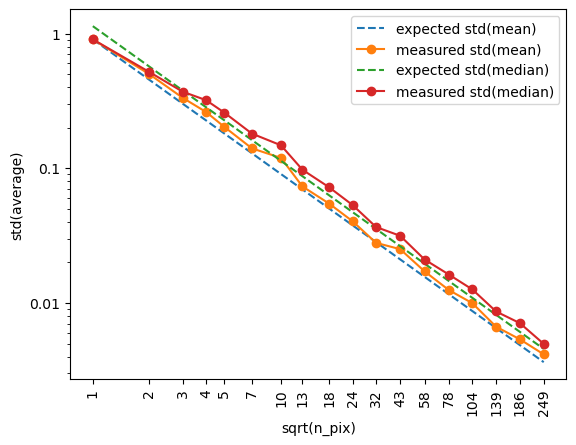

In [ ]:
background_stats_plot(results_no_bkg)

What about if the pixels are a bit correlated (i.e. by a convolution)?

In [ ]:
results_no_bkg_convolved = stats_versus_size(
    random_convolved, mask, n_apertures=100, max_sqrt_n_pix=250, aperture_shape="square"
)

100%|██████████| 18/18 [00:02<00:00,  8.34it/s]


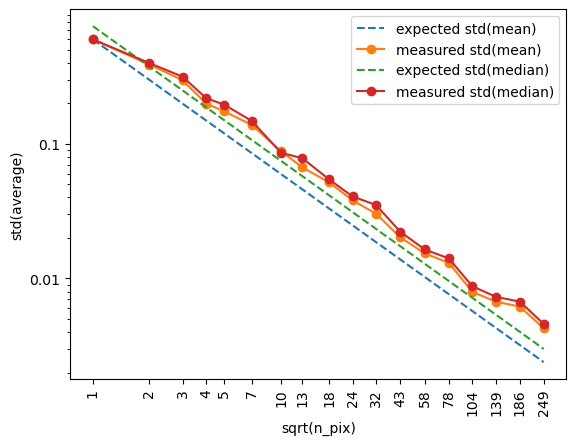

In [ ]:
background_stats_plot(results_no_bkg_convolved)

And now with a spatially varying background.

In [ ]:
results_with_bkg = stats_versus_size(
    random_with_background,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=250,
    aperture_shape="square",
)

100%|██████████| 18/18 [00:01<00:00, 10.95it/s]


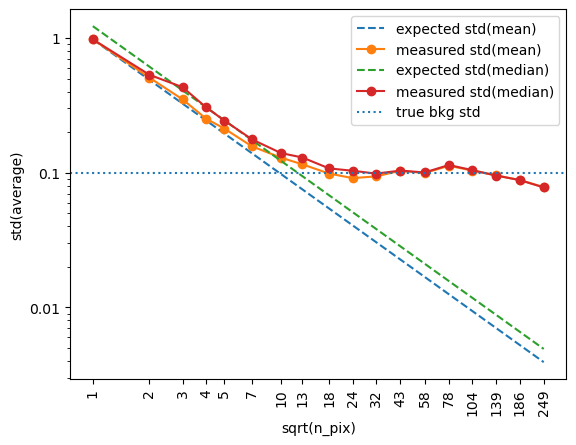

In [ ]:
background_stats_plot(results_with_bkg, true_bkg_std=0.1)

And again, what about if the pixels are a bit correlated (i.e. by a convolution)?

In [ ]:
results_with_bkg_convolved = stats_versus_size(
    random_with_background_convolved,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=250,
    aperture_shape="square",
)

  0%|          | 0/18 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:02<00:00,  8.21it/s]


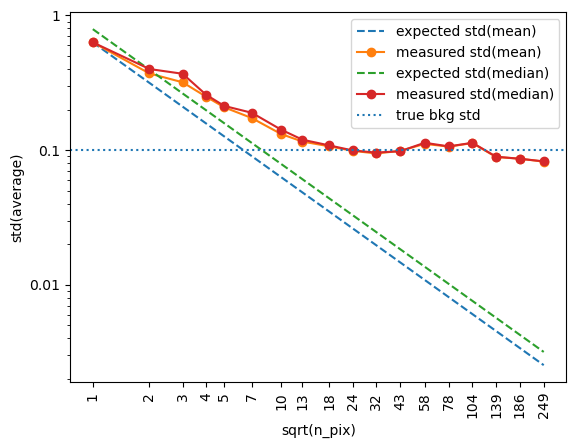

In [ ]:
background_stats_plot(results_with_bkg_convolved, true_bkg_std=0.1)

Create a background containing spatial variations with a different rms, to compare.

In [ ]:
random, background, random_with_background = create_test_background(background_rms=0.2)

In [ ]:
results_with_bkg = stats_versus_size(
    random_with_background,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=250,
    aperture_shape="square",
)

100%|██████████| 18/18 [00:02<00:00,  8.88it/s]


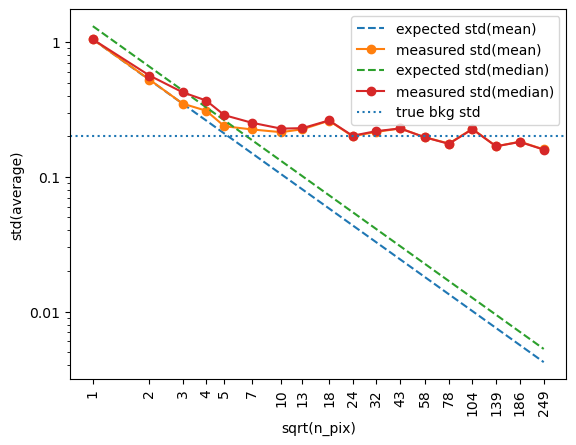

In [ ]:
background_stats_plot(results_with_bkg, true_bkg_std=0.2)

Create a background containing spatial variations on a different scale, to compare.

In [ ]:
random, background, random_with_background = create_test_background(
    background_scale=10
)

In [ ]:
random_convolved = correlate_pixels(random, slope=0.8)
random_with_background_convolved = random_convolved + background

Fraction of flux in central pixel is 56%


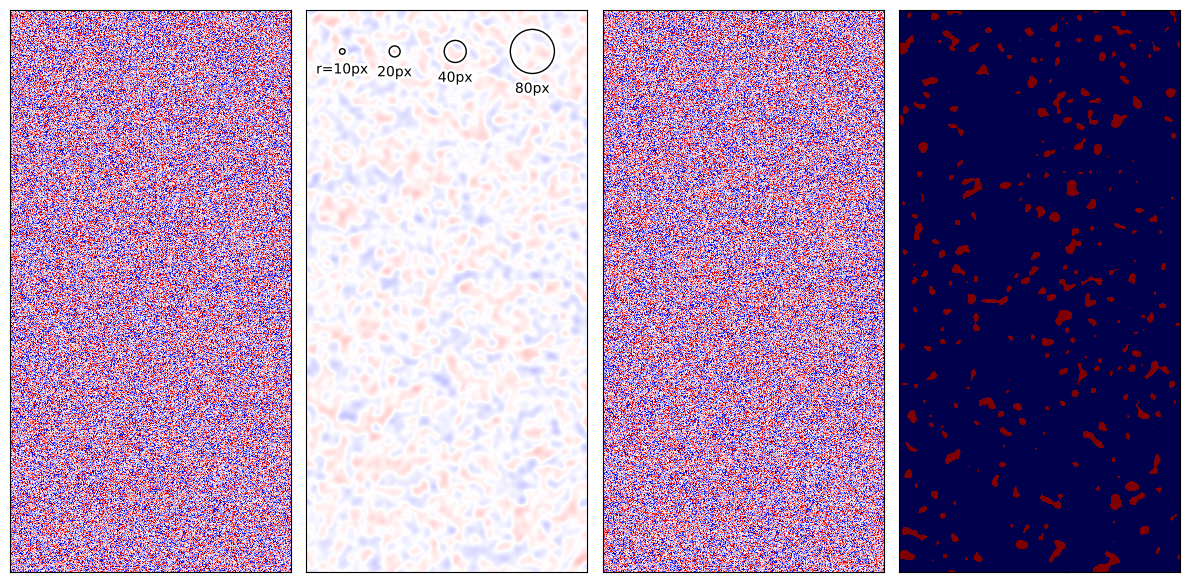

In [ ]:
plot_test_images(random, background, random_with_background, mask)

In [ ]:
results_with_bkg = stats_versus_size(
    random_with_background,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=250,
    aperture_shape="square",
)

100%|██████████| 18/18 [00:02<00:00,  8.37it/s]


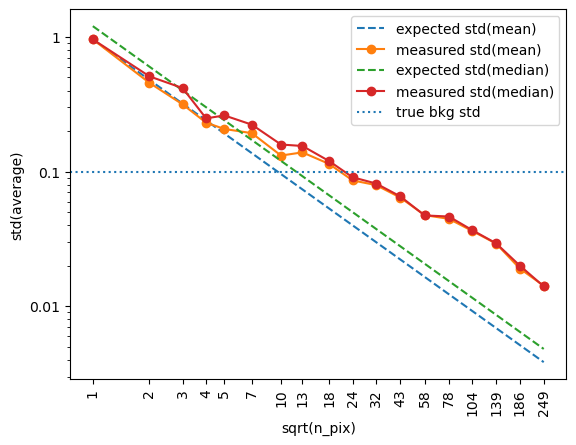

In [ ]:
background_stats_plot(results_with_bkg, true_bkg_std=0.1)

In [ ]:
results_with_bkg_convolved = stats_versus_size(
    random_with_background_convolved,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=250,
    aperture_shape="square",
)

100%|██████████| 18/18 [00:02<00:00,  8.38it/s]


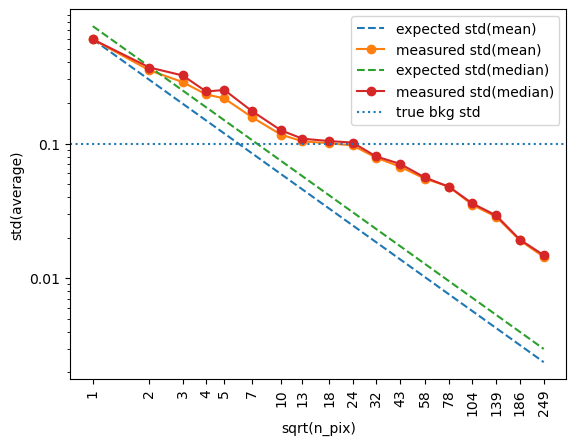

In [ ]:
background_stats_plot(results_with_bkg_convolved, true_bkg_std=0.1)

## Example

The following is an example of using `measure` on an observation.

100%|██████████| 21/21 [00:57<00:00,  2.73s/it]


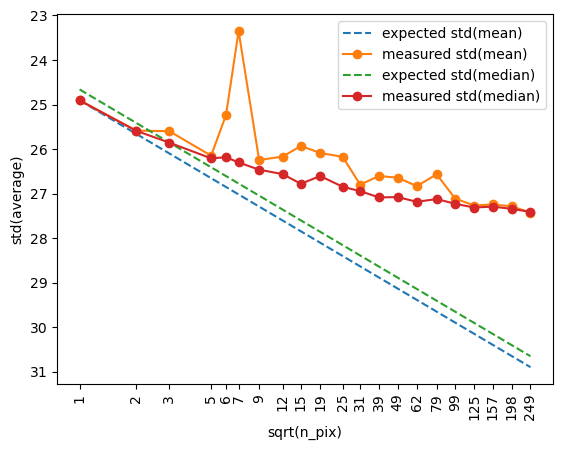

In [ ]:
path = default_data_path("Q1_R1_processed_v0.4")
filename = "NIR/2682/EUC_NIR_W-STK_Y_2682.fits"
results = measure(filename, path / "stacked_original")

100%|██████████| 21/21 [00:33<00:00,  1.61s/it]


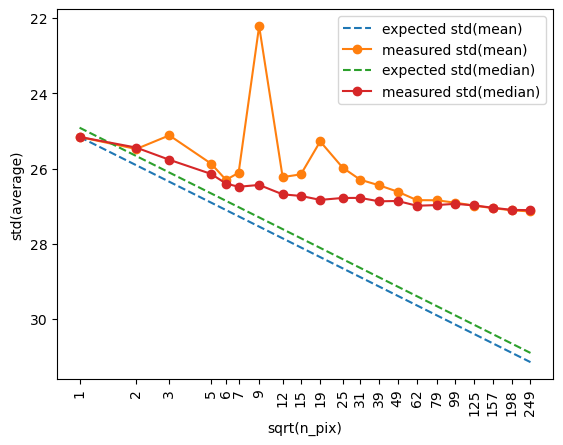

In [ ]:
path = default_data_path("Q1_R1_processed_v0.4")
filename = "NIR/2682/EUC_NIR_W-STK_Y_2682.fits"
results = measure(filename , path / "stacked_no_bkg")

100%|██████████| 21/21 [00:36<00:00,  1.75s/it]


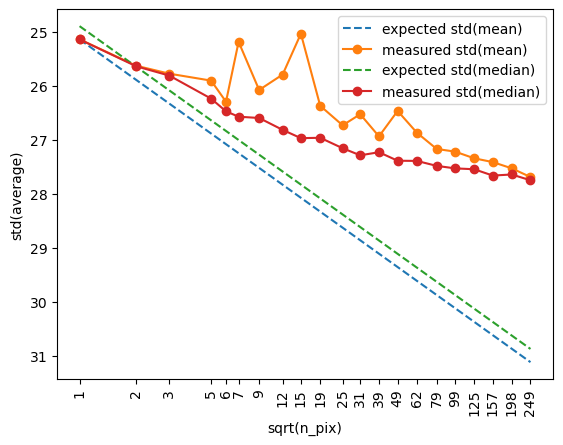

In [ ]:
path = default_data_path("Q1_R1_processed_v0.4")
filename = "NIR/2682/EUC_NIR_W-STK_Y_2682.fits"
results = measure(filename, path / "stacked")

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()